In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,           # Show ticks on top
    'xtick.bottom': True,        # Show ticks on bottom
    'ytick.left': True,          # Show ticks on left
    'ytick.right': True,         # Show ticks on right
    'xtick.minor.visible': True, # Show minor ticks
    'ytick.minor.visible': True, # Show minor ticks
    'xtick.labelsize': 11,       # X-axis tick label size
    'ytick.labelsize': 11,       # Y-axis tick label size
    'font.size': 11,
    'axes.labelsize': 14,
    'axes.titlesize': 13,
    'legend.fontsize': 13,
    'legend.framealpha': 1.0,    # Fully opaque legend background
    'legend.facecolor': 'white', # White legend background
    'legend.edgecolor': 'black', # Black legend border
    'legend.fancybox': False,    # Square (not rounded) corners
    'figure.titlesize': 14,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
})

## Figure 1: Cross-hand phase Secondary proof of concept

Sep 06 -20.512153625
Sep 08 -22.611122131
Sep 16 -12.720323563
Sep 23 -20.680635452
Oct 01 -21.870855331
Oct 06 -23.212997437
Oct 14 -23.688835144
Oct 22 -23.838336945
Oct 28 -22.951351166
Nov 06 -22.685415268
Nov 12 -25.058416367
Nov 18 -21.451889038
Nov 25 -21.220342636
Feb 10 -20.782705307
Feb 19 -22.974252701
Feb 25 -21.345500946
Mar 31 -22.445703506


/tmp/ipykernel_1266412/4056591085.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


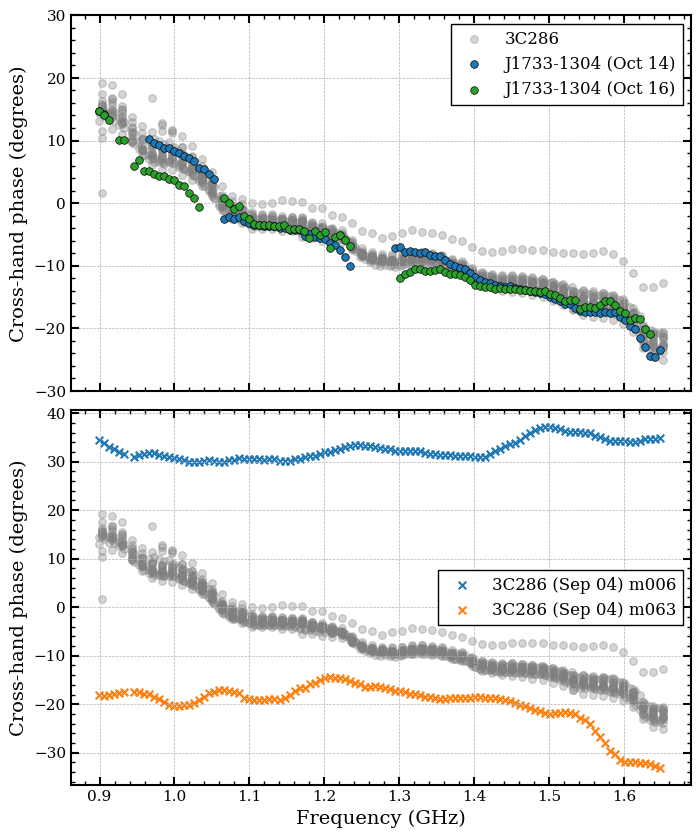

In [4]:
# RUN PULL_XF_TO_FILES.py first to generate the .txt files from the Xf tables,
# then this cell reads those files and makes the plot.

from pathlib import Path
from datetime import datetime
import re
import numpy as np
import matplotlib.pyplot as plt

XF_DIR = Path('../files/crosshand_phase_files')

# ── Helper: extract date label from filename (CODE_YYYYMMDD_FIELD_XF.txt) ─────
def date_label(p: Path) -> str:
    m = re.search(r'_(\d{8})_', p.name)
    if m:
        return datetime.strptime(m.group(1), '%Y%m%d').strftime('%b %d')
    return p.stem

# ── Auto-load all 3C286 (J1331) and J1733 Xf exports ─────────────────────────
xf_3c286 = sorted(XF_DIR.glob('*J1331*_XF.txt'))
xf_j1733 = sorted(XF_DIR.glob('*J1733*_XF.txt'))

data_3c286 = [(date_label(p), np.loadtxt(p)) for p in xf_3c286]
data_j1733 = [(date_label(p), np.loadtxt(p)) for p in xf_j1733]

# ── Manual loads (antenna-specific) ──────────────────────────────────────────
sep04_xftab_3c286_m006 = np.loadtxt(XF_DIR / 'Sep04_crosshand_phase_solution_xftab_3c286_m006.txt')
sep04_xftab_3c286_m063 = np.loadtxt(XF_DIR / 'Sep04_crosshand_phase_solution_xftab_3c286_m063.txt')

# ── Colours for J1733 epochs ──────────────────────────────────────────────────
j1733_colours = ['C0', 'C2', 'C2', 'C3', 'C4', 'C5']

fig, ax = plt.subplots(2, 1, figsize=(8, 10), sharex=True, gridspec_kw={'hspace': 0.05})

# ── SUBPLOT 1 ─────────────────────────────────────────────────────────────────

# 3C286 Xf solutions — grey circles, low alpha
for i, (label, d) in enumerate(data_3c286):
    ax[0].scatter(d[:, 0]/1e9, d[:, 1], s=30, color='grey', marker='o',
                  alpha=0.33, label='3C286' if i == 0 else '_nolegend_')

    print(label, d[-1,1])

# J1733-1304 solutions — coloured circles with black edges
for i, (label, d) in enumerate(data_j1733):
    ax[0].scatter(d[:, 0]/1e9, d[:, 1], s=30, color=j1733_colours[i], marker='o',
                  edgecolors='black', linewidths=0.5,
                  label=f'J1733-1304 ({label})', zorder=10000)

ax[0].grid(True, which='major', linestyle='--', linewidth=0.5)
ax[0].set_ylabel('Cross-hand phase (degrees)')
ax[0].set_ylim(-30, 30)
ax[0].legend(loc='upper right', fontsize=12)


# ── SUBPLOT 2 ─────────────────────────────────────────────────────────────────

# 3C286 Xf solutions — grey circles, low alpha
for i, (label, d) in enumerate(data_3c286):
    ax[1].scatter(d[:, 0]/1e9, d[:, 1], s=30, color='grey', marker='o',
                  alpha=0.33)

ax[1].scatter(sep04_xftab_3c286_m006[:, 0]/1e9, sep04_xftab_3c286_m006[:, 1],
              s=30, color='C0', marker='x', label='3C286 (Sep 04) m006')
ax[1].scatter(sep04_xftab_3c286_m063[:, 0]/1e9, sep04_xftab_3c286_m063[:, 1],
              s=30, color='C1', marker='x', label='3C286 (Sep 04) m063')

ax[1].set_xlabel('Frequency (GHz)')
ax[1].set_ylabel('Cross-hand phase (degrees)')
ax[1].grid(True, which='major', linestyle='--', linewidth=0.5)
ax[1].legend(loc='center right', fontsize=12)


# ── Output ────────────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('../plots/methods/method_crosshand_phase_proof_of_concept.png', bbox_inches='tight')
plt.show()

## Figure 2: Super-Gaussian FDF schematic

Illustrates the super-Gaussian Faraday dispersion function (FDF) shape parameter $N$
from Anderson et al. (2016), as implemented in `faraday_utils.ThickComponent`.

The normalised profile is:

$$F(\varphi) \propto \exp\!\left(-\frac{|\varphi - \varphi_\mathrm{peak}|^N}{2\,\sigma_\varphi^N}\right)$$

Two Faraday dispersion widths are shown ($\sigma_\varphi = 10$ and $40\;\mathrm{rad\,m^{-2}}$) as
**solid** and **dashed** lines respectively.  Different values of $N$ are shown in different colours:
$N=2$ (Gaussian / burn screen), through to $N=50$ (top-hat / burn slab limit).


σ_rm = 10 rad m⁻²
     N       ∫F dφ (numerical)
--------------------------------
     2                0.987581
     3                0.999964
     4                1.000000
     6                1.000000
    10                1.000000
    15                1.000000
    30                1.000000
    50                1.000000
Saved: ../plots/methods/method_super_gaussian_schematic.pdf


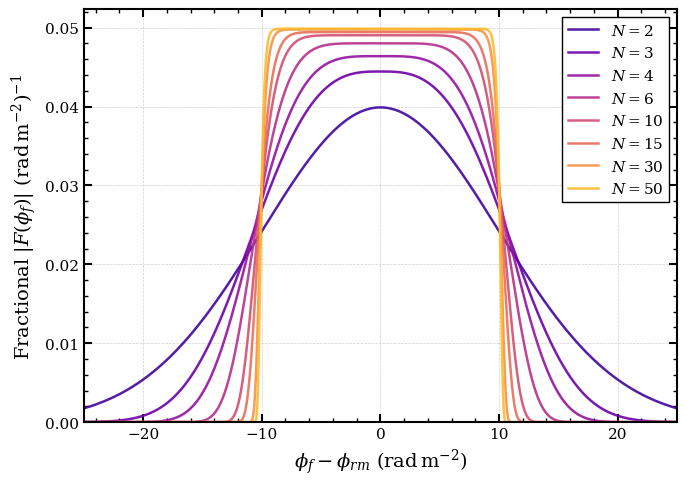

In [5]:
from scipy.special import gamma as scipy_gamma

def plot_super_gaussian_schematic(
    sigma_rm=10,
    N_values=(2, 3, 4, 6, 10, 20, 30, 50),
    phi_range=(-40, 40),
    n_points=2000,
    figsize=(7, 5),
    save_path=None,
):
    """
    Plot a schematic of normalised super-Gaussian FDF profiles for a single sigma_rm.

    The profile is:
        F(φ) = (1/C_norm) * exp(-|φ|^N / (2*σ_rm^N))
    where
        C_norm = 2^(1+1/N) * σ_rm * Γ(1/N) / N

    Parameters
    ----------
    sigma_rm : float
        Faraday dispersion width in rad m⁻².
    N_values : tuple of float
        Shape parameters to show.
    phi_range : tuple of float
        φ axis limits in rad m⁻²  (centred on φ_peak = 0).
    n_points : int
        Number of φ grid points.
    figsize : tuple
        Figure size.
    save_path : str or Path or None
        If given, save figure to this path.

    Returns
    -------
    matplotlib.figure.Figure
    """
    phi = np.linspace(phi_range[0], phi_range[1], n_points)
    dphi = phi[1] - phi[0]

    colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(N_values)))

    fig, ax = plt.subplots(figsize=figsize)

    print(f"σ_rm = {sigma_rm} rad m⁻²")
    print(f"{'N':>6}  {'∫F dφ (numerical)':>22}")
    print("-" * 32)

    for n_idx, N in enumerate(N_values):
        color = colors[n_idx]

        # Normalisation constant (Anderson et al. 2016)
        C_norm = 2 ** (1 + 1 / N) * sigma_rm * scipy_gamma(1 / N) / N

        # Profile (φ_peak = 0 for schematic)
        with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
            ratio = np.abs(phi) / sigma_rm
            log_ratio_N = np.where(ratio > 0, N * np.log(ratio), -np.inf)
            log_ratio_N = np.clip(log_ratio_N, -np.inf, 700.0)
            exponent = -0.5 * np.exp(log_ratio_N)
            exponent = np.where(np.abs(phi) > 0, exponent, 0.0)

        profile = np.exp(exponent) / C_norm

        # Numerical integral (trapezoid rule) — should equal 1
        integral = np.trapz(profile, dx=dphi)
        print(f"{N:>6}  {integral:>22.6f}")

        ax.plot(phi, profile, color=color, linewidth=1.8,
                label=f'$N = {N}$', alpha=0.9)

    ax.set_xlabel(r'$\phi_f - \phi_{rm}\ \mathrm{(rad\,m^{-2})}$')
    ax.set_ylabel(r'Fractional $|F(\phi_f)|\ \mathrm{(rad\,m^{-2})^{-1}}$')
    ax.set_xlim(phi_range)
    ax.set_ylim(bottom=0)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.6)
    ax.legend(loc='upper right', framealpha=1.0, edgecolor='black',
              fancybox=False, fontsize=11, ncol=1)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
        print(f"Saved: {save_path}")

    return fig


# ── Run ──────────────────────────────────────────────────────────────────────
fig = plot_super_gaussian_schematic(
    sigma_rm=10,
    N_values=(2, 3, 4, 6, 10, 15, 30, 50),
    phi_range=(-25, 25),
    save_path='../plots/methods/method_super_gaussian_schematic.pdf',
)
plt.show()


## Figure 3: Polarization angle prior

The intrinsic polarization angle $\psi_0$ is sampled with a von Mises-like prior
$f(\psi) \propto \exp(k \cos 4\psi)$, which is $\pi$-periodic over the domain $[-90°, 90°)$.
Setting $k = 0$ recovers a uniform (uninformative) prior — the case used throughout the fits presented here.
The prior transform is constructed via a numerical inverse-CDF so that dynesty receives unit-cube samples.

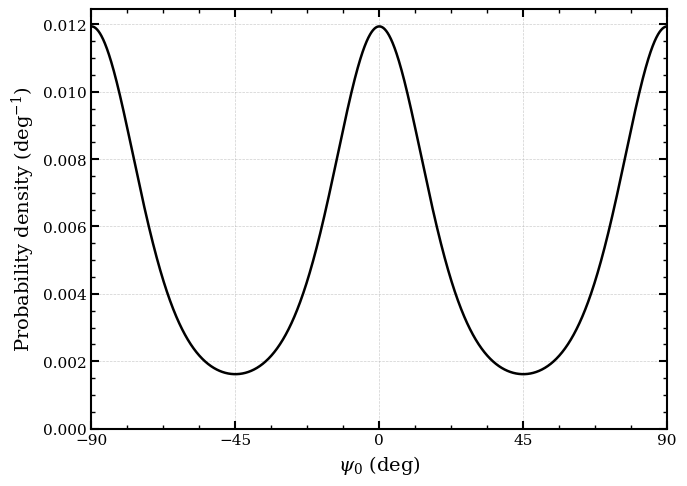

In [6]:
from scipy.interpolate import interp1d

def _build_angle_prior_transform(k, n_grid=10_000):
    """Numerical inverse-CDF for f(psi) ∝ exp(k cos(4 psi)), domain [-90, 90)."""
    theta = np.linspace(-90, 90, n_grid, endpoint=False)
    log_p = k * np.cos(4 * np.deg2rad(theta))
    p = np.exp(log_p - log_p.max())
    cdf = np.cumsum(p)
    cdf = (cdf - cdf[0]) / (cdf[-1] - cdf[0])
    return interp1d(cdf, theta, bounds_error=False, fill_value=(theta[0], theta[-1]))

rng_prior = np.random.default_rng(42)
k = 1.0

theta_grid = np.linspace(-90, 90, 2000, endpoint=False)
log_p = k * np.cos(4 * np.deg2rad(theta_grid))
p = np.exp(log_p - log_p.max())
p /= np.trapz(p, theta_grid)

inv_cdf = _build_angle_prior_transform(k)
samples = inv_cdf(rng_prior.uniform(0, 1, 50_000))

fig_prior, ax_prior = plt.subplots(figsize=(7, 5))

#ax_prior.hist(samples, bins=90, range=(-90, 90), density=True,
              #color='C0', alpha=0.45, label='Sampled density')
ax_prior.plot(theta_grid, p, color='black', linewidth=1.8, label='PDF ($k = 0$)')

ax_prior.set_xlabel(r'$\psi_0$ (deg)')
ax_prior.set_ylabel(r'Probability density (deg$^{-1}$)')
ax_prior.set_xlim(-90, 90)
ax_prior.set_xticks([-90, -45, 0, 45, 90])
ax_prior.set_ylim(bottom=0)
#ax_prior.legend(loc='upper right')
ax_prior.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.6)

plt.tight_layout()
fig_prior.savefig('../plots/methods/method_angle_prior.pdf', bbox_inches='tight')
plt.show()

## Figure 4: Radio continuum image raster

A 1×4 raster showing zoomed cutouts of Swift J1727.8−1613 at two epochs
(Oct 2023 and Feb 2024) in Stokes I and linearly polarized intensity.
Each panel is centred 15 pixels south of the image phase centre.
Contours are drawn at 3, 5, 10, 20, and 50× the local rms noise.
The archival VLA position (Plotkin et al.) is marked with a red star.
The synthesised beam is shown as a white ellipse in the lower-left corner of each panel.

Stokes I Beam: 8.0348×5.0371'', PA=144.88 deg, pix=0.0003 deg
Lin. Pol. Beam: 8.0348×5.0371'', PA=144.88 deg, pix=0.0003 deg
Stokes I Beam: 9.0475×5.3735'', PA=128.08 deg, pix=0.0003 deg
Lin. Pol. Beam: 9.0475×5.3735'', PA=128.08 deg, pix=0.0003 deg
Saved: ../plots/methods/method_four_panel_raster.pdf


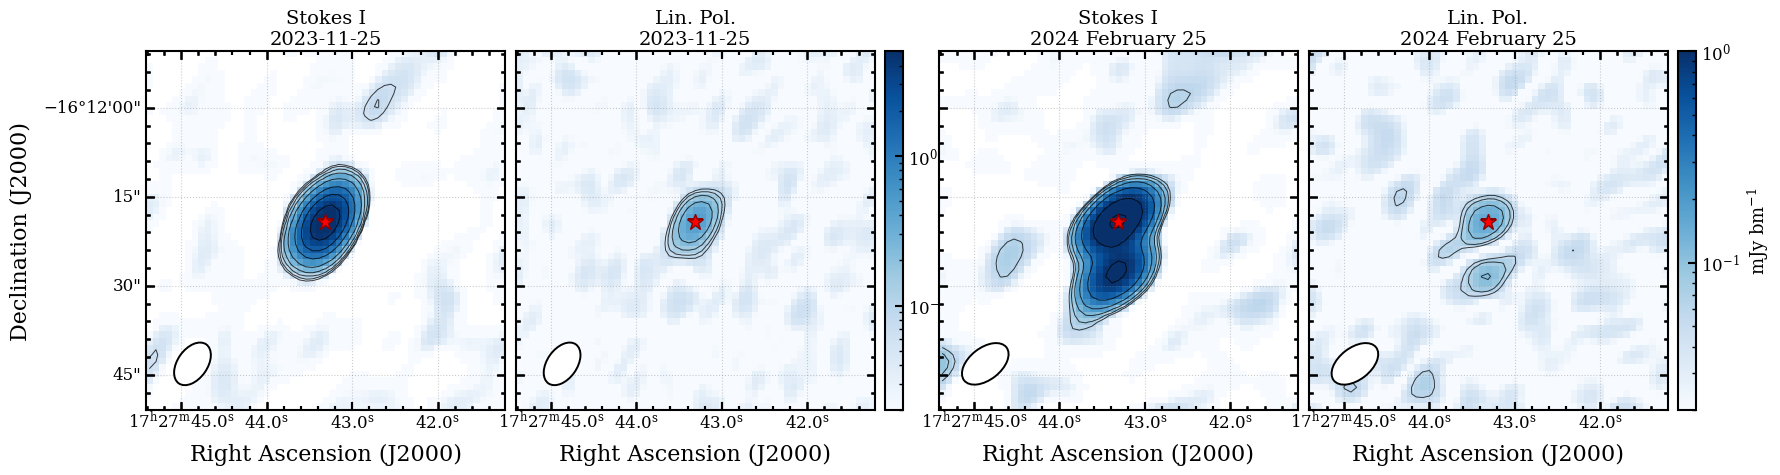

In [16]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib.patches import Ellipse
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec

# ── Image paths ───────────────────────────────────────────────────────────────
early_stokes_I = '../fits_images/img_1700905354_sdp_l0_1024ch_SwiftJ1727.ms_pcalmask_zoom-MFS-I-image.fits'
early_stokes_P = '../fits_images/img_1700905354_sdp_l0_1024ch_SwiftJ1727.ms_pcalmask_zoom-MFS-Plin-image.fits'
late_stokes_I = '../fits_images/img_1708829174_sdp_l0_1024ch_SwiftJ1727.ms_pcalmask_zoom-MFS-I-image.fits'
late_stokes_P = '../fits_images/img_1708829174_sdp_l0_1024ch_SwiftJ1727.ms_pcalmask_zoom-MFS-Plin-image.fits'

ARCHIVAL_POS = SkyCoord("17h27m43.31s -16d12m19.23s", frame='icrs')

TITLE_FS    = 14
LABEL_FS    = 16
TICK_FS     = 12
CBAR_FS     = 12
CBAR_LBL_FS = 13


def plot_four_panel_raster(
    panels,                              # list of (fits_path, panel_label, rms_mjy) × 4
    cutout_size_asec = 60.0,
    y_offset_pix    = -15,
    cmap            = 'Blues',
    contour_sigmas  = (3, 5, 10, 20, 50),
    source_pos      = ARCHIVAL_POS,
    vmin_mjy        = (0.02, 0.02),     # log lower limit per epoch pair: (early, late)
    vmax_mjy        = (2.0,  0.5),      # log upper limit per epoch pair: (early, late)
    stokes_i_freqs  = (1.65, 1.26),     # centre frequency (GHz) for each Stokes I panel
    save_path       = None,
):
    """
    1×4 raster. Panels 0-1 = early epoch; panels 2-3 = late epoch.
    Each pair gets its own colorbar and LogNorm, making vmin/vmax independently
    configurable per epoch via the vmin_mjy and vmax_mjy 2-tuples.
    Colorbars are resized after drawing to match the image y-axis extent.
    Titles include the observation date read from DATE-OBS in the FITS header.
    Each panel tuple includes: (fits_path, panel_label, rms_mjy_for_contours)
    stokes_i_freqs: (early_GHz, late_GHz) — annotated top-right on Stokes I panels.
    """
    assert len(panels) == 4

    # One LogNorm per epoch pair (index 0 = early, index 1 = late)
    norms = [
        LogNorm(vmin=vmin_mjy[0], vmax=vmax_mjy[0]),
        LogNorm(vmin=vmin_mjy[1], vmax=vmax_mjy[1]),
    ]

    # GridSpec layout: [p0 | p1 | cb_early | gap | p2 | p3 | cb_late]
    fig = plt.figure(figsize=(20, 5))
    fig.patch.set_facecolor('white')
    gs = gridspec.GridSpec(
        1, 7,
        figure=fig,
        width_ratios=[1, 1, 0.05, 0.04, 1, 1, 0.05],
        wspace=0.05,
    )

    gs_col_map   = [0, 1, 4, 5]   # GridSpec column for each panel
    gs_cbar_cols = [2, 6]          # colorbar columns

    axes_dummy = [fig.add_subplot(gs[0, c]) for c in gs_col_map]
    cbar_axes  = [fig.add_subplot(gs[0, c]) for c in gs_cbar_cols]

    wcs_axes     = []
    pair_last_im = [None, None]    # last imshow per epoch pair
    stokes_i_count = 0             # tracks which Stokes I panel we're on

    for col, (img_path, panel_label, rms_mjy) in enumerate(panels):
        with fits.open(img_path) as hdul:
            hdu = hdul[0]
            hdr = hdu.header

            bmaj_deg = hdr.get('BMAJ', 0.001)
            bmin_deg = hdr.get('BMIN', 0.001)
            bpa_deg  = hdr.get('BPA',  0.0)
            pix_deg  = abs(hdr['CDELT2'])

            print(panel_label, f"Beam: {bmaj_deg*3600:.4f}×{bmin_deg * 3600:.4f}'', PA={bpa_deg:.2f} deg, pix={pix_deg:.4f} deg")

            date_obs = hdr.get('DATE-OBS', '')
            obs_day  = date_obs[:10] if date_obs else ''

            wcs2d  = WCS(hdr, naxis=2)
            data2d = hdu.data.squeeze()
            ny, nx = data2d.shape

            cx, cy     = nx // 2, ny // 2 + y_offset_pix
            centre_sky = wcs2d.pixel_to_world(cx, cy)
            size       = u.Quantity(cutout_size_asec, u.arcsec)
            cutout     = Cutout2D(data2d, centre_sky, size, wcs=wcs2d)

        axes_dummy[col].remove()
        ax = fig.add_subplot(gs[0, gs_col_map[col]], projection=cutout.wcs)
        wcs_axes.append(ax)

        cdata = cutout.data * 1e3   # → mJy/beam

        # Use the norm for this epoch pair
        im = ax.imshow(cdata, origin='lower', cmap=cmap,
                       norm=norms[col // 2], interpolation='nearest')
        pair_last_im[col // 2] = im

        levels = [s * rms_mjy for s in contour_sigmas]
        ax.contour(cdata, levels=levels, colors='k',
                   linewidths=0.7, alpha=0.75, zorder=3)

        if source_pos is not None:
            try:
                sx, sy = cutout.wcs.world_to_pixel(source_pos)
                ax.plot(sx, sy, marker='*', markersize=12,
                        color='red', markeredgecolor='darkred',
                        markeredgewidth=1.0, zorder=10)
            except Exception:
                pass

        # Beam ellipse – lower-left
        bx = 0.12 * cutout.data.shape[1]
        by = 0.12 * cutout.data.shape[0]
        beam = Ellipse(
            (bx, by),
            width  = bmin_deg / pix_deg,
            height = bmaj_deg / pix_deg,
            angle  = (bpa_deg),
            facecolor='white', edgecolor='black',
            linewidth=1.4, zorder=8,
        )
        ax.add_patch(beam)

        title_str = f'{panel_label}\n{obs_day}' if obs_day else panel_label
        ax.set_title(
            title_str.replace('-10-', ' October ').replace('-02-', ' February '),
            fontsize=TITLE_FS, pad=5,
        )

        # Frequency label in top-right of Stokes I panels
        if panel_label == 'Stokes I' and stokes_i_count < len(stokes_i_freqs):
            freq_ghz = stokes_i_freqs[stokes_i_count]
            # ax.text(0.97, 0.1, f'~{freq_ghz:.2f} GHz',
            #         transform=ax.transAxes,
            #         fontsize=LABEL_FS, color='black',
            #         ha='right', va='top', fontweight='bold',
            #         bbox=dict(facecolor='none', edgecolor='none', pad=1.0),
            #         zorder=20)
            stokes_i_count += 1

        ax.coords[0].set_axislabel('Right Ascension (J2000)', fontsize=LABEL_FS)
        ax.coords[0].set_axislabel_position('b')
        ax.coords[0].set_major_formatter('hh:mm:ss.s')
        ax.coords[0].set_ticklabel(size=TICK_FS)

        if col == 0:
            ax.coords[1].set_axislabel('Declination (J2000)', fontsize=LABEL_FS)
            ax.coords[1].set_axislabel_position('l')
            ax.coords[1].set_major_formatter('dd:mm:ss')
            ax.coords[1].set_ticklabel(size=TICK_FS)
        else:
            ax.coords[1].set_axislabel('')
            ax.coords[1].set_ticklabel_visible(False)

        ax.grid(True, ls=':', lw=0.8, color='gray', alpha=0.4)

    fig.canvas.draw()

    lbl      = r'mJy bm$^{-1}$'
    ref_axes = [wcs_axes[1], wcs_axes[3]]

    for cb_ax, ref_ax, im in zip(cbar_axes, ref_axes, pair_last_im):
        pos_img = ref_ax.get_position()
        pos_cb  = cb_ax.get_position()
        cb_ax.set_position([pos_cb.x0, pos_img.y0, pos_cb.width, pos_img.height])
        cb = fig.colorbar(im, cax=cb_ax)
        cb.ax.tick_params(labelsize=CBAR_FS)
        cb.set_label(lbl, fontsize=CBAR_LBL_FS)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight', dpi=200)
        print(f"Saved: {save_path}")

    return fig, wcs_axes


# ── Run ───────────────────────────────────────────────────────────────────────
panels = [
    (early_stokes_I, 'Stokes I', 0.02),
    (early_stokes_P, 'Lin. Pol.', 0.025),
    (late_stokes_I, 'Stokes I', 0.02),
    (late_stokes_P, 'Lin. Pol.', 0.018),
]

fig_raster, ax_raster = plot_four_panel_raster(
    panels,
    cutout_size_asec = 60.0,
    y_offset_pix     = -15,
    cmap             = 'Blues',
    contour_sigmas   = (3, 4, 6, 10, 20, 50, 100, 200),
    # contour_sigmas   = (10, 20, 50),
    source_pos       = ARCHIVAL_POS,
    vmin_mjy         = (0.02, 0.02),   # (early vmin, late vmin)  mJy/beam
    vmax_mjy         = (5.0,  1.0),  # (early vmax, late vmax)  mJy/beam
    stokes_i_freqs   = (1.28,1.28),  # (early GHz, late GHz)
    save_path        = '../plots/methods/method_four_panel_raster.pdf',
)
plt.show()